In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from kneed import KneeLocator
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import silhouette_score

from sklearn.datasets import fetch_20newsgroups


## **1. Problem Definition**

In this project, we aim to automatically group news articles using unsupervised machine learning techniques. Given a dataset of 20 newsgroup, our goal is to apply clustering algorithms (such as K-Means, Hierarchical Clustering, and Gaussian Mixture Models) to organize documents into meaningful groups based on their textual content.

## **2. Data Collection & loading and Analyzing**

In [36]:
# Load dataset
newsgroups = fetch_20newsgroups(
    subset='all',
    categories=['comp.sys.ibm.pc.hardware', 'rec.sport.hockey', 'talk.politics.mideast'],
    remove=('headers', 'footers', 'quotes')
)

# Create dataframe
data = pd.DataFrame({
    'text': newsgroups.data,
    'target': newsgroups.target,
    'target_name': [newsgroups.target_names[i] for i in newsgroups.target]
})

print(data.shape)
data.head()

(2921, 3)


,text,target,target_name
0,\n\nI don't have the faintest idea what litera...,2,talk.politics.mideast
1,"\nI have two SCSI hard drives, each has 512KB ...",0,comp.sys.ibm.pc.hardware
2,\n\n\nIt is not a question of an individuals s...,2,talk.politics.mideast
3,\nYes. As long as the goverment over there can...,2,talk.politics.mideast
4,"I currently have a AD-lib card, it can play .m...",0,comp.sys.ibm.pc.hardware


In [37]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2921 entries, 0 to 2920
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   text         2921 non-null   object
 1   target       2921 non-null   int64 
 2   target_name  2921 non-null   object
dtypes: int64(1), object(2)
memory usage: 68.6+ KB


In [38]:
data.isnull().sum()

text           0
target         0
target_name    0
dtype: int64

In [39]:
print(len(newsgroups.target_names))
print(newsgroups.target_names)

3
['comp.sys.ibm.pc.hardware', 'rec.sport.hockey', 'talk.politics.mideast']


## **3. Data Preprocessing & Cleaning**

In [40]:
from utils import clean_text

In [ ]:
data_preprocessed = data.copy()

# Apply the preprocessing function to the 'text' column
data_preprocessed.loc[:, "text"] = data_preprocessed["text"].apply(clean_text)

In [8]:
data_preprocessed.head()

,text,target,target_name
0,\n\n sure basher pen fan pretty confused lack ...,10,rec.sport.hockey
1,brother market highperformance video card supp...,3,comp.sys.ibm.pc.hardware
2,\n\n\n\n\t finally say dream mediterranean new...,17,talk.politics.mideast
3,\n think \n\n scsi card dma transfer disk \n\n...,3,comp.sys.ibm.pc.hardware
4,old jasmine drive use new system \n unde...,4,comp.sys.mac.hardware


## **4. Feature Extraction**

#### Shows the most important words across the dataset

In [42]:
from utils.feature_extraction import train_feature_extractor

In [43]:
# vectorizer words
X_tfidf = train_feature_extractor(data_preprocessed)

Fitting 2 folds for each of 5 candidates, totalling 10 fits


Best max_features: 1356
Vectorizer saved to: models/tfidf_vectorizer.pkl


In [48]:
data_matrix = X_tfidf[0]
data_matrix.shape

(2921, 1356)

/tmp/ipykernel_82046/2176415845.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_scores, y=top_words, palette="viridis")


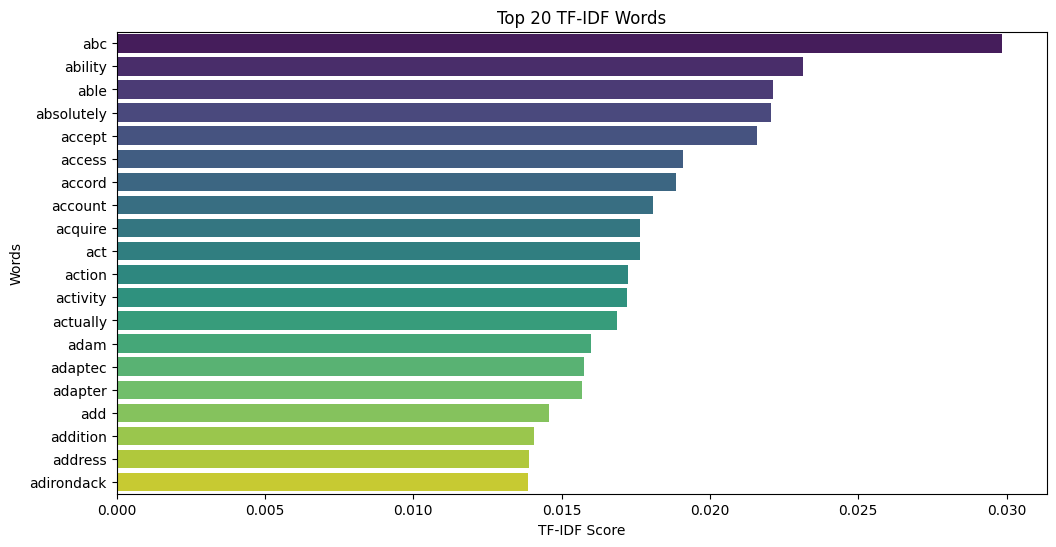

In [49]:
top_words = list(X_tfidf[1])[:20]
top_scores = list(X_tfidf[2].values())[:20]

plt.figure(figsize=(12, 6))
sns.barplot(x=top_scores, y=top_words, palette="viridis")
plt.xlabel("TF-IDF Score")
plt.ylabel("Words")
plt.title(f"Top {20} TF-IDF Words")
plt.show()

## **5. Apply Clustering Algorithms**

In [50]:
def optimal_cluster_count(data):
    inertia = []
    for k in range(1, 11):  
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(data)
        inertia.append(kmeans.inertia_)
    knee = KneeLocator(range(1, 11), inertia, curve="convex", direction="decreasing")
    optimal_k = knee.elbow

    return optimal_k, inertia

### choose the optimal number of cluster

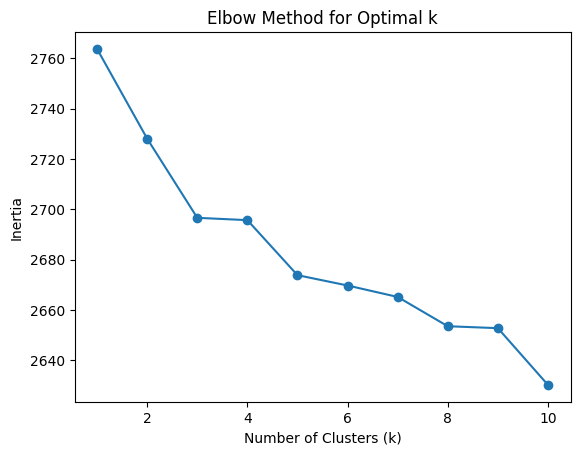

In [51]:
inertia = optimal_cluster_count(data_matrix)[1]
# Plot the elbow method graph
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

In [52]:
optimal_k = int(optimal_cluster_count(data_matrix)[0])
print("The optimal the number of clusters is: ", optimal_k)

The optimal the number of clusters is:  5


### Apply KMeans clustering

In [56]:
# Apply KMeans clustering with the optimal k
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(data_matrix)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [57]:
kmeans_labels = kmeans.predict(data_matrix.toarray())
data_preprocessed['KMeans_Clusters'] = kmeans_labels
data_preprocessed[["target_name", "KMeans_Clusters"]].head()

,target_name,KMeans_Clusters
0,talk.politics.mideast,1
1,comp.sys.ibm.pc.hardware,2
2,talk.politics.mideast,1
3,talk.politics.mideast,1
4,comp.sys.ibm.pc.hardware,2


### Apply Hierarchical Clustering

In [58]:
hierarchical = linkage(data_matrix.toarray(), method='ward')
hierarchical_labels = fcluster(hierarchical, 3, criterion='distance')


In [59]:
data_preprocessed['hierarchical_Clusters'] = hierarchical_labels
data_preprocessed[["target_name", "hierarchical_Clusters"]].head()

,target_name,hierarchical_Clusters
0,talk.politics.mideast,29
1,comp.sys.ibm.pc.hardware,2
2,talk.politics.mideast,38
3,talk.politics.mideast,34
4,comp.sys.ibm.pc.hardware,12


### Apply Gaussian Mixture Model Clustering

In [61]:
gmm = GaussianMixture(n_components=3, random_state=42)
gmm.fit(data_matrix.toarray(), 3)

,"n_components n_components: int, default=1The number of mixture components.",3
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [62]:
gmm_labels = gmm.predict(data_matrix.toarray())
data_preprocessed['gmm_Clusters'] = gmm_labels
data_preprocessed[["target_name", "gmm_Clusters"]].head()

,target_name,gmm_Clusters
0,talk.politics.mideast,1
1,comp.sys.ibm.pc.hardware,2
2,talk.politics.mideast,1
3,talk.politics.mideast,1
4,comp.sys.ibm.pc.hardware,2


## **6. Evaluate the Clustering Performance**

In [63]:
# evaluate Kmeans model
score = silhouette_score(data_matrix, kmeans_labels)
print(f"Silhouette Score: {score}")

Silhouette Score: 0.016194557233587564


In [64]:
# evaluate hierarchical model
score = silhouette_score(data_matrix, hierarchical_labels)
print(f"Silhouette Score: {score}")

Silhouette Score: 0.013321762360694659


In [65]:
# evaluate gmm model
score = silhouette_score(data_matrix, gmm_labels)
print(f"Silhouette Score: {score}")

Silhouette Score: 0.01069630763892109


## **7. Visualize Results**

In [66]:
from scipy.cluster.hierarchy import dendrogram
from sklearn.decomposition import PCA

In [67]:
# Reduce dimensions to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(data_matrix.toarray())

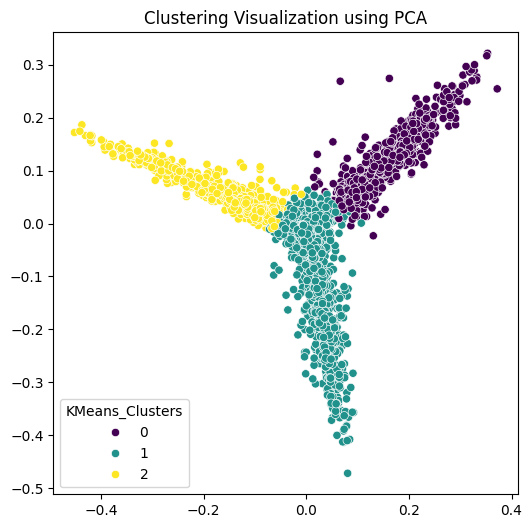

In [68]:
# Plot Kmens clusters
plt.figure(figsize=(6, 6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=data_preprocessed["KMeans_Clusters"], palette="viridis")
plt.title("Clustering Visualization using PCA")
plt.show()

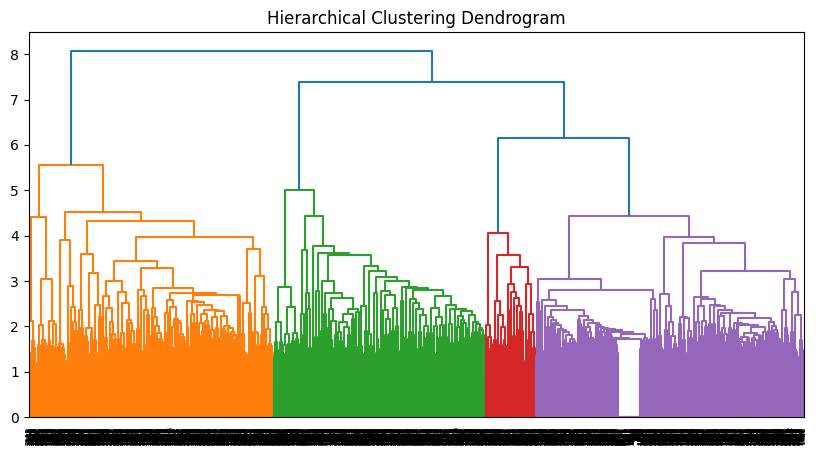

In [69]:
# Plot hierarchical dendrogram
plt.figure(figsize=(10, 5))
dendrogram(hierarchical)
plt.title("Hierarchical Clustering Dendrogram")
plt.show()


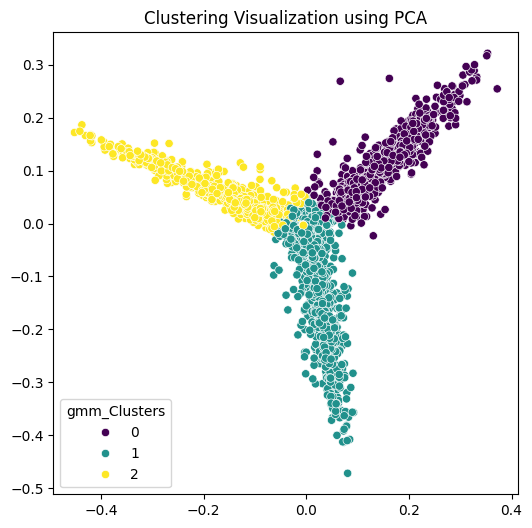

In [70]:
# Plot gmm clusters
plt.figure(figsize=(6, 6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=data_preprocessed["gmm_Clusters"], palette="viridis")
plt.title("Clustering Visualization using PCA")
plt.show()

In [71]:
import joblib
# Load model
kmeans_model = joblib.dump(filename="kmeans_news_model.pkl", value = kmeans)